In [1]:
# plot std and leave data plot as option

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

#from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, WhiteKernel, Matern, RBF

In [3]:
df = pd.read_csv("data/cleaned_data_no_control.csv")
df["rxn_concentration"] = df.concentration * df.volume
df["rxn_concentration_log"] = np.log1p(df["rxn_concentration"])
df = df.rename(columns={
    "concentration": "additive_concentration",
    "Minutes_Between_LastAddition_and_Scan": "scan_minutes"
})

num_cols = ["rxn_concentration_log", "temp", "scan_minutes"]
cat_col  = ["additive"] 
target_col = "lambda max wavelength" 

#X_num = df[num_cols].to_numpy(dtype=float)
#encoder = OneHotEncoder(drop="if_binary", sparse_output=False)
encoder = OneHotEncoder(sparse_output=False)
X_cat = encoder.fit_transform(df[cat_col]) 

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(df[num_cols])

X = np.hstack([X_num_scaled, X_cat])
y = df[target_col].to_numpy(dtype=float)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [5]:
n_features = X_train.shape[1]
# kernel = (
#     Matern(length_scale=np.ones(n_features), length_scale_bounds=(1e-2, 1e2), nu=1.5)
#     + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e0))
# )

kernel = (
    RBF(length_scale=np.ones(n_features), length_scale_bounds=(1e-2, 1e2))
    + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-8, 1e-2))
)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,      
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=0,
)

In [6]:
gpr.fit(X_train, y_train)
y_mean, y_std = gpr.predict(X_test, return_std=True)

print("Learned kernel:", gpr.kernel_)

Learned kernel: RBF(length_scale=[0.427, 0.24, 1.35, 0.01, 0.129, 0.01, 0.149, 0.01, 0.01, 0.01]) + WhiteKernel(noise_level=0.01)


/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/audreymarthin/anaconda3/lib/pytho

In [66]:
def plot_1d(
    gpr,
    df,
    num_cols,
    encoder,
    scaler,
    feature,
    fixed_additive,
    target_col="wavelength",
    grid_size=200
):

    f_idx = num_cols.index(feature)
    x_vals = np.linspace(df[feature].min(), df[feature].max(), grid_size)
    mean_vals = df[num_cols].mean().to_numpy()
    X_full = np.zeros((grid_size, len(num_cols) + len(encoder.categories_[0])))

    # fill all numeric values with mean, then overwrite one column
    for i in range(len(num_cols)):
        X_full[:, i] = mean_vals[i]

    X_full[:, f_idx] = x_vals

    X_num_scaled = scaler.transform(X_full[:, :len(num_cols)])
    add_vec = encoder.transform([[fixed_additive]])[0]
    X_gp = np.hstack([X_num_scaled, np.tile(add_vec, (grid_size, 1))])
    mean, std = gpr.predict(X_gp, return_std=True)
    mask = df["additive"] == fixed_additive

    plt.figure(figsize=(7,5))
    plt.scatter(
        df.loc[mask, feature],
        df.loc[mask, target_col],
        s=18,
        color="black",
        label="Observations"
    )
    plt.plot(x_vals, mean, color="blue", label="Mean prediction")
    plt.fill_between(
        x_vals,
        mean - 1.96 * std,
        mean + 1.96 * std,
        alpha=0.3,
        color="skyblue",
        label="95% CI"
    )

    plt.xlabel(feature)
    plt.ylabel(target_col)
    plt.title(f"GP for {feature} (additive={fixed_additive})")
    plt.legend()
    plt.show()

/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


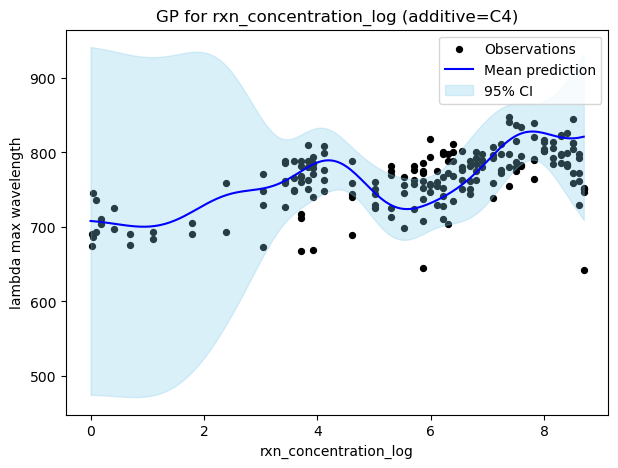

In [67]:
plot_1d(
    gpr=gpr,
    df=df,
    num_cols=["rxn_concentration_log", "temp", "scan_minutes"],
    encoder=encoder,
    scaler=scaler,
    feature="rxn_concentration_log",
    fixed_additive="C4",
    target_col="lambda max wavelength"
)

In [9]:
def plot_2d(
    gpr,
    df,
    num_cols,
    encoder,
    scaler,
    feature_x,
    feature_y,
    fixed_additive,
    target_col="wavelength",
    grid_size=60
):
    ix = num_cols.index(feature_x)
    iy = num_cols.index(feature_y)

    # Case 1 - default: feature is in raw space, leave ON
    #
    x_vals = np.linspace(df[feature_x].min(), df[feature_x].max(), grid_size)
    y_vals = np.linspace(df[feature_y].min(), df[feature_y].max(), grid_size)
  
    # Case 2 - log : feature stored as log(...) in df
    # - COMMENT OUT the block above
    # - UNCOMMENT the block below
    #
    # x_vals = np.linspace(
    #     df[feature_x].min(),
    #     df[feature_x].max(),
    #     grid_size
    # )
    # y_vals = np.linspace(
    #     df[feature_y].min(),
    #     df[feature_y].max(),
    #     grid_size
    # )

    Xg, Yg = np.meshgrid(x_vals, y_vals)
    mean_vals = scaler.mean_
    X_full = np.tile(mean_vals, (grid_size * grid_size, 1))

    X_full[:, ix] = Xg.ravel()
    X_full[:, iy] = Yg.ravel()
    X_num_scaled = scaler.transform(X_full)

    add_vec = encoder.transform([[fixed_additive]])[0]
    X_cat_block = np.tile(add_vec, (grid_size * grid_size, 1))
    X_gp = np.hstack([X_num_scaled, X_cat_block])

    mean_pred, std_pred = gpr.predict(X_gp, return_std=True)
    Z = mean_pred.reshape(grid_size, grid_size)
    Z_std = std_pred.reshape(grid_size, grid_size)

    mask = df["additive"] == fixed_additive
    plt.figure(figsize=(8,6))

    # Default: plot in feature space as used by GP
    plt.contourf(Xg, Yg, Z, levels=30, cmap="viridis")
    plt.scatter(
        df.loc[mask, feature_x],
        df.loc[mask, feature_y],
        c=df.loc[mask, target_col],
        edgecolor="k",
        s=25
    )

    # Optional: Plot back unloged units
    # - COMMENT OUT the block above
    # - UNCOMMENT the block below
    #
    # plt.contourf(
    #     np.expm1(Xg),
    #     np.expm1(Yg),
    #     Z,
    #     levels=30,
    #     cmap="viridis"
    # )
    # plt.scatter(
    #     np.expm1(df.loc[mask, feature_x]),
    #     np.expm1(df.loc[mask, feature_y]),
    #     c=df.loc[mask, target_col],
    #     edgecolor="k",
    #     s=25
    # )

    plt.colorbar(label="Predicted " + target_col)
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.title(f"GP mean: {feature_x} vs {feature_y} | additive={fixed_additive}")
    plt.show()

    plt.figure(figsize=(8,6))
    plt.contourf(Xg, Yg, Z_std, levels=30, cmap="inferno")
    plt.colorbar(label="Predictive std")
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.title(f"GP uncertainty: {feature_x} vs {feature_y} | additive={fixed_additive}")
    plt.show()


/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


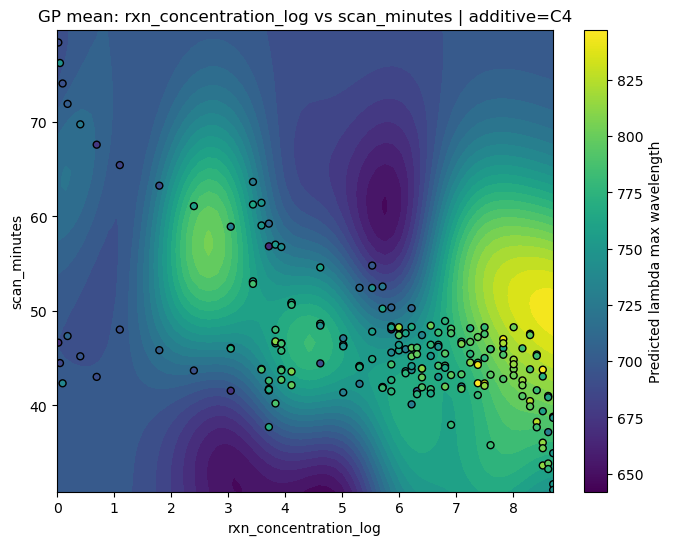

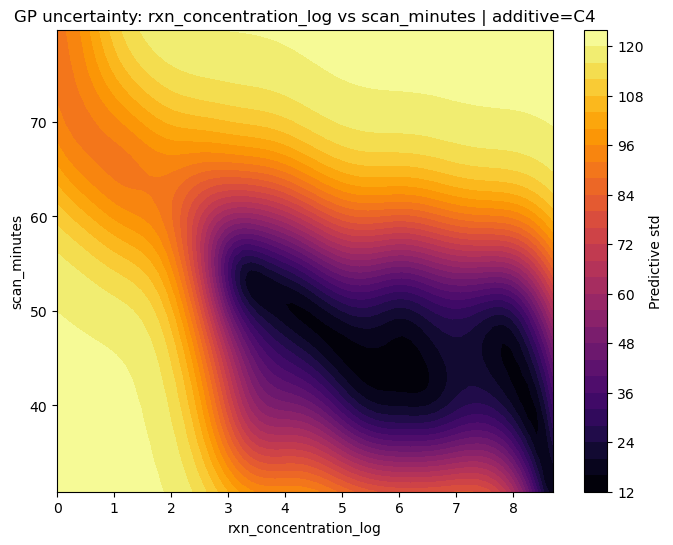

In [10]:
plot_2d(
    gpr=gpr,
    df=df,
    num_cols=["rxn_concentration_log", "temp", "scan_minutes"],
    encoder=encoder,
    scaler=scaler,
    feature_x="rxn_concentration_log",
    feature_y="scan_minutes",
    fixed_additive="C4",
    target_col="lambda max wavelength"
)

In [11]:
def plot_3d(
    gpr,
    df,
    num_cols,
    encoder,
    scaler,
    feature_x,
    feature_y,
    fixed_additive,
    target_col="lambda max wavelength",
    grid_size=40
):
    # indices of the two features we are plotting
    ix = num_cols.index(feature_x)
    iy = num_cols.index(feature_y)

    # build grid for the two chosen features
    x = np.linspace(df[feature_x].min(), df[feature_x].max(), grid_size)
    y = np.linspace(df[feature_y].min(), df[feature_y].max(), grid_size)
    Xg, Yg = np.meshgrid(x, y)

    base_vals = df[num_cols].mean().to_numpy()
    X_num = np.tile(base_vals, (grid_size * grid_size, 1))
    X_num[:, ix] = Xg.ravel()
    X_num[:, iy] = Yg.ravel()
    X_num_scaled = scaler.transform(X_num)

    add_vec = encoder.transform([[fixed_additive]])[0]
    X_cat = np.tile(add_vec, (grid_size * grid_size, 1))
    X_gp = np.hstack([X_num_scaled, X_cat])

    mean, std = gpr.predict(X_gp, return_std=True)
    Z_mean = mean.reshape(grid_size, grid_size)
    Z_std = std.reshape(grid_size, grid_size)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    # OPTION A: Mean prediction surface 
    ax.plot_surface(
        Xg, Yg, Z_mean,
        cmap="viridis",
        edgecolor="none",
        alpha=0.9
    )

    # OPTION B: Training data points 
    # mask = df["additive"] == fixed_additive
    
    # ax.scatter(
    #     df.loc[mask, feature_x],
    #     df.loc[mask, feature_y],
    #     df.loc[mask, target_col],
    #     color="black",
    #     s=25,
    #     label="Observations"
    # )

    # OPTION C: Color by uncertainty 
    # surf = ax.plot_surface(
    #     Xg, Yg, Z_mean,
    #     facecolors=plt.cm.coolwarm(Z_std / Z_std.max()),
    #     edgecolor="none",
    #     alpha=0.9
    # )
    
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.set_zlabel(target_col)
    ax.set_title(f"GP surface ({feature_x} vs {feature_y}, additive={fixed_additive})", pad=8, y=0.98)

    ax.view_init(elev=25, azim=-60)
    zmin, zmax = Z_mean.min(), Z_mean.max()
    ax.set_zlim(zmin, zmax + 0.05 * (zmax - zmin))
    ax.set_box_aspect((1, 1, 0.7))
    ax.zaxis.set_tick_params(pad=9)
    
    plt.tight_layout()
    plt.show()

/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


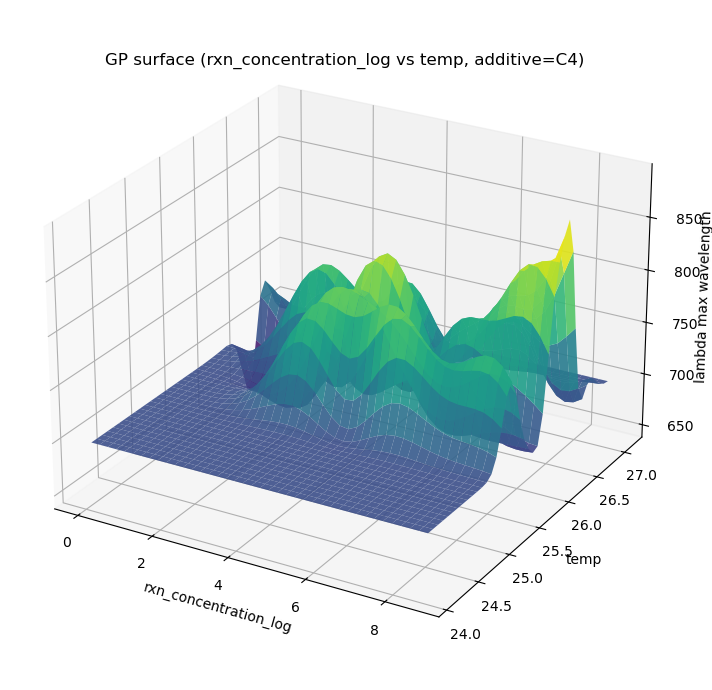

In [12]:
plot_3d(
    gpr=gpr,
    df=df,
    num_cols=num_cols,
    encoder=encoder,
    scaler=scaler,
    feature_x="rxn_concentration_log",
    feature_y="temp",
    fixed_additive="C4",
    target_col="lambda max wavelength",
    grid_size=40,
)
